In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re  # This is for "Regular Expressions" (cleaning text)

# Load the data - remember your file doesn't have headers (column names)
# So we must define them manually
cols = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_Content']
df = pd.read_csv('twitter_training.csv', names=cols, header=None)

# Let's see the first 5 rows to confirm it loaded
df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Tweet_ID           0
Entity             0
Sentiment          0
Tweet_Content    686
dtype: int64

Total duplicate rows: 2700


In [5]:
# 1. Remove the 686 rows with missing Tweet_Content
df.dropna(subset=['Tweet_Content'], inplace=True)

# 2. Remove the 2,700 duplicate rows
df.drop_duplicates(inplace=True)

# 3. Define the cleaning function to strip out the 'noise'
def clean_tweet(text):
    # Ensure text is a string
    text = str(text).lower()
    # Remove @mentions
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    # Remove URLs (http/https)
    text = re.sub(r'http\S+', '', text)
    # Remove special characters and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = " ".join(text.split())
    return text

# 4. Apply the function to create a new 'Clean_Tweet' column
df['Clean_Tweet'] = df['Tweet_Content'].apply(clean_tweet)

# 5. Final check: Remove any rows that became empty after cleaning
df = df[df['Clean_Tweet'] != '']

print(f"Cleaning complete! New total rows: {len(df)}")
df[['Tweet_Content', 'Clean_Tweet']].head()

Cleaning complete! New total rows: 71316


,Tweet_Content,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


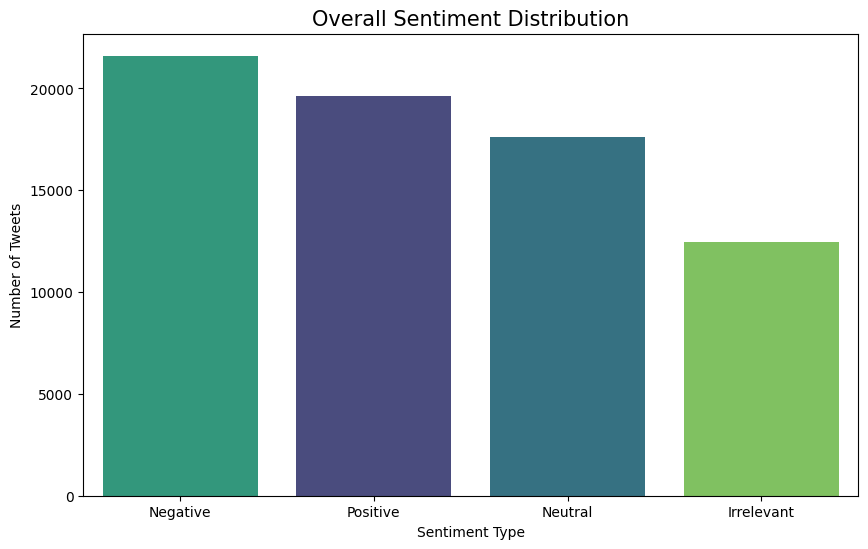

Sentiment
Negative      21605
Positive      19644
Neutral       17593
Irrelevant    12474
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 6))

# 1. Get the order of sentiments from highest to lowest count
sentiment_order = df['Sentiment'].value_counts().index

# 2. Create the plot
sns.countplot(
    data=df, 
    x='Sentiment', 
    order=sentiment_order, 
    hue='Sentiment',      
    palette='viridis', 
    legend=False          # <--- Hides the legend since it's redundant here
)

plt.title('Overall Sentiment Distribution', fontsize=15)
plt.xlabel('Sentiment Type')
plt.ylabel('Number of Tweets')
plt.show()

# Let's see the exact counts
print(df['Sentiment'].value_counts())

Negative sentiment is the most frequent, followed by Positive. This is typical for gaming/tech data where users are more likely to post when they have a grievance (bugs/lag) or high excitement (new releases).

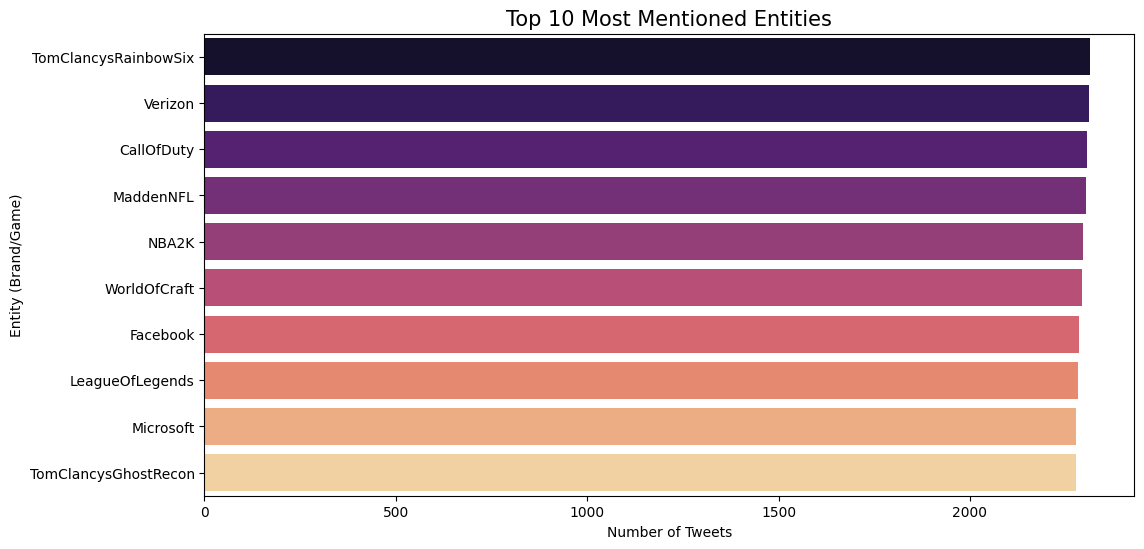

The most mentioned entity is: TomClancysRainbowSix


In [8]:
# Get the top 10 entities by tweet count
top_10_entities = df['Entity'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_entities.values, 
    y=top_10_entities.index, 
    hue=top_10_entities.index, 
    palette='magma',
    legend=False
)

plt.title('Top 10 Most Mentioned Entities', fontsize=15)
plt.xlabel('Number of Tweets')
plt.ylabel('Entity (Brand/Game)')
plt.show()

print("The most mentioned entity is:", top_10_entities.index[0])

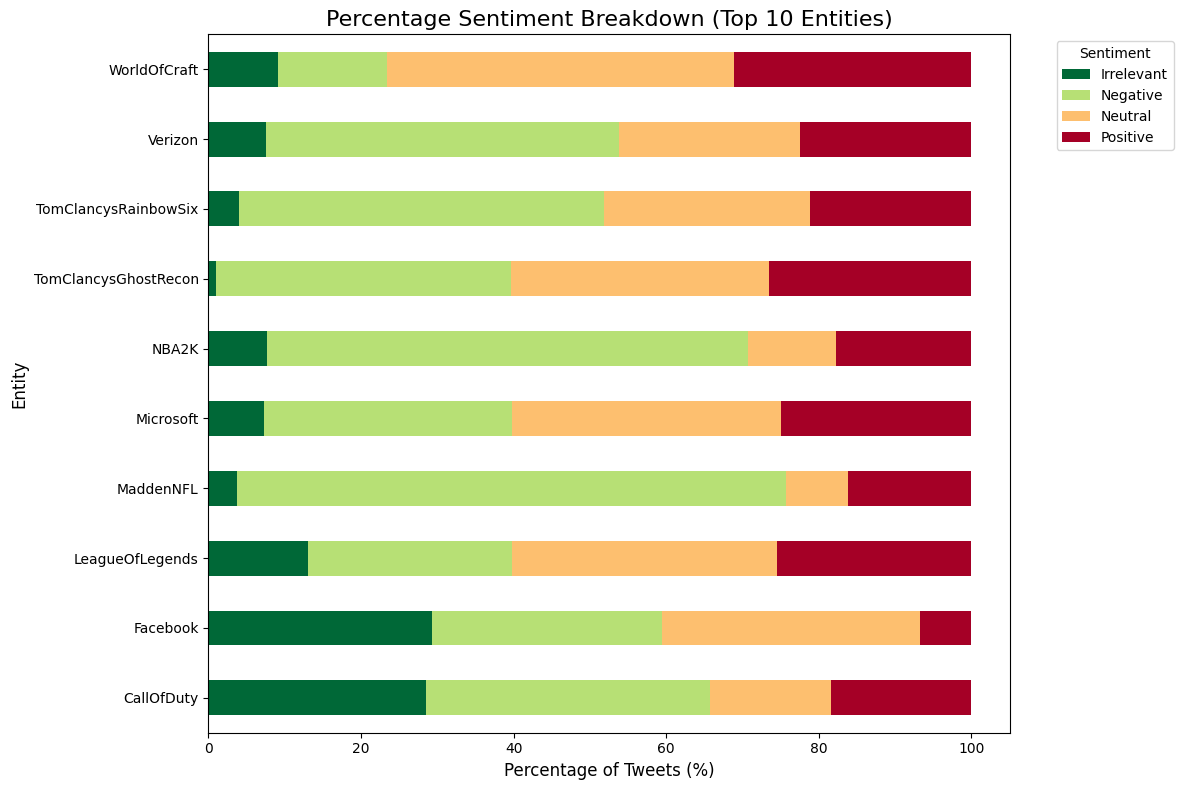

In [12]:
# 1. Get the Top 10 entities names
top_10_list = df['Entity'].value_counts().head(10).index
df_top10 = df[df['Entity'].isin(top_10_list)]

# 2. Create a crosstab (counts of sentiment per entity)
sentiment_counts = pd.crosstab(df_top10['Entity'], df_top10['Sentiment'])

# 3. Normalize the data (Convert counts to percentages that add up to 100%)
sentiment_percentage = sentiment_counts.divide(sentiment_counts.sum(axis=1), axis=0) * 100

# 4. Plot the Normalized Stacked Bar Chart
sentiment_percentage.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='RdYlGn_r')

plt.title('Percentage Sentiment Breakdown (Top 10 Entities)', fontsize=16)
plt.xlabel('Percentage of Tweets (%)', fontsize=12)
plt.ylabel('Entity', fontsize=12)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


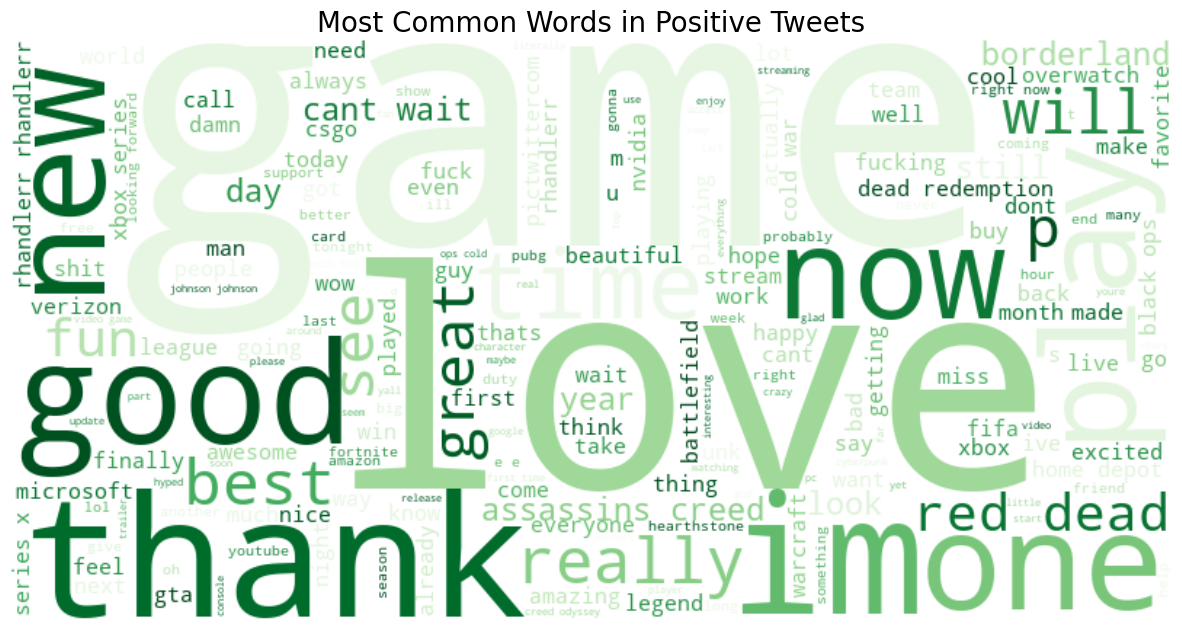

In [20]:
from wordcloud import WordCloud

# 1. Filter for only Positive tweets
positive_tweets = df[df['Sentiment'] == 'Positive']['Clean_Tweet'].str.cat(sep=' ')

# 2. Create the Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_tweets)

# 3. Plot it
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Tweets', fontsize=20)
plt.show()

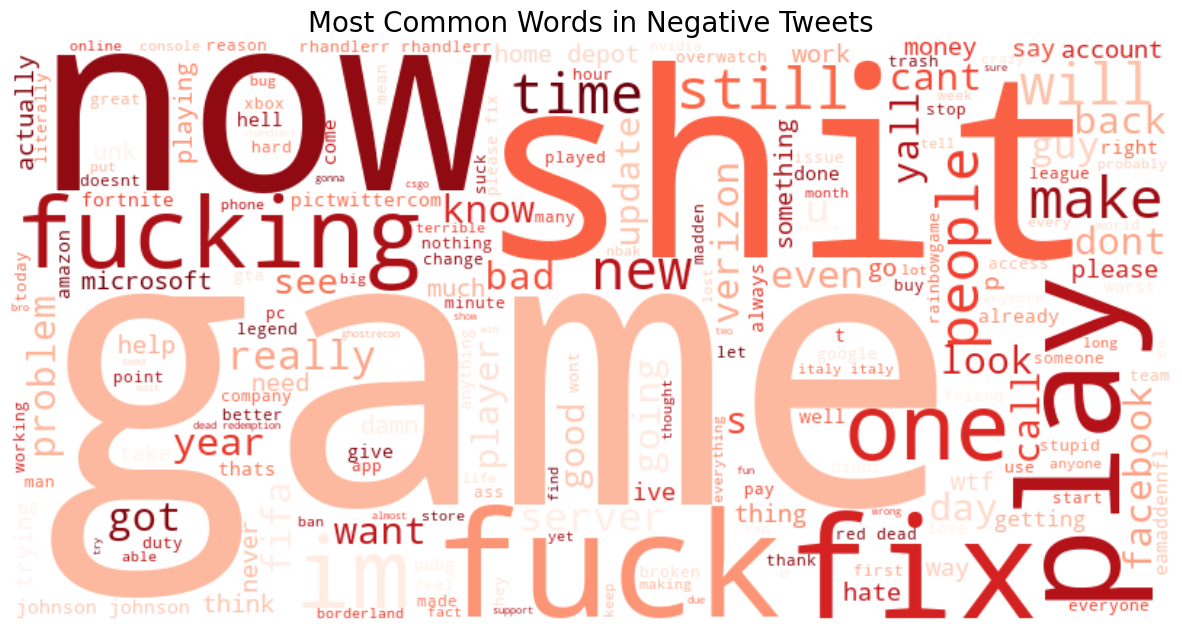

In [19]:

# 1. Combine all Negative tweets into one string
negative_tweets = df[df['Sentiment'] == 'Negative']['Clean_Tweet'].str.cat(sep=' ')

# 2. Create the Word Cloud (using 'Reds' for a negative look)
wordcloud_neg = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='Reds'
).generate(negative_tweets)

# 3. Plot it
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Tweets', fontsize=20)
plt.show()

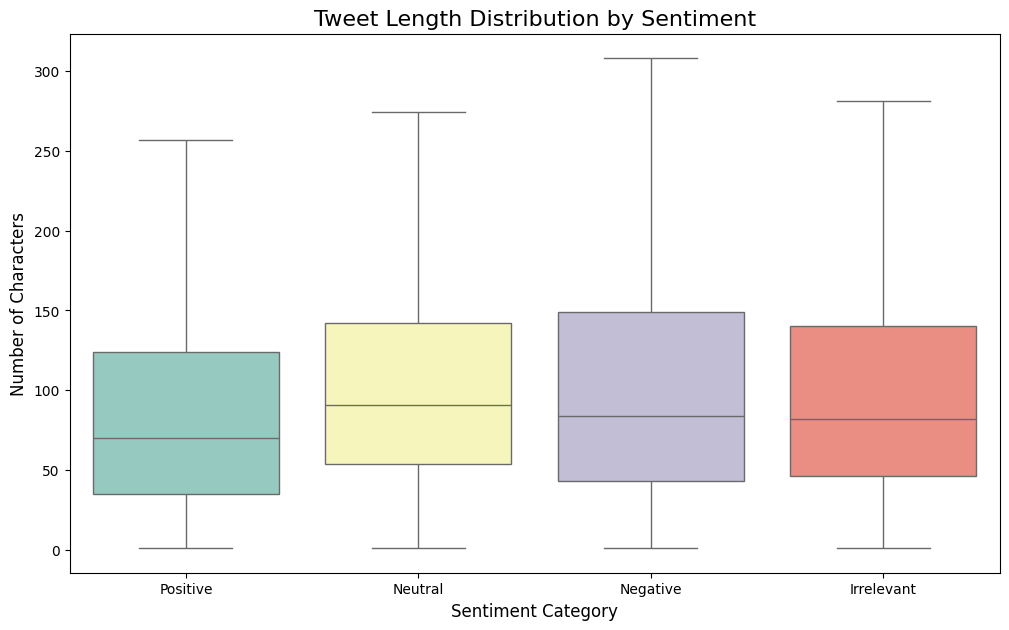

Average Tweet Length:
Sentiment
Irrelevant    100.834776
Negative      102.918399
Neutral       104.832206
Positive       89.057575
Name: Tweet_Length, dtype: float64


In [16]:
# 1. Calculate length for each tweet
df['Tweet_Length'] = df['Clean_Tweet'].apply(len)

# 2. Create a Box Plot to see the distribution
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df, 
    x='Sentiment', 
    y='Tweet_Length', 
    hue='Sentiment', 
    palette='Set3', 
    showfliers=False # Removes extreme outliers to keep the chart clean
)

plt.title('Tweet Length Distribution by Sentiment', fontsize=16)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Characters', fontsize=12)
plt.show()

# 3. See the average length numerically
print("Average Tweet Length:")
print(df.groupby('Sentiment')['Tweet_Length'].mean())

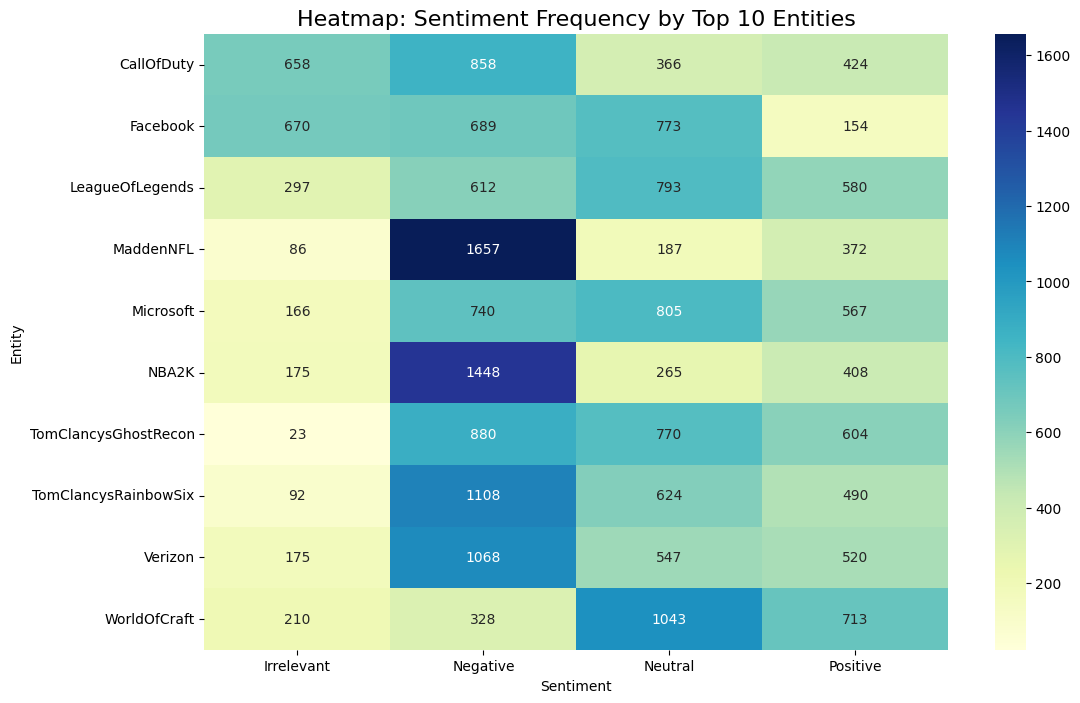

In [22]:
# heatmap of Sentiment vs Entity for the Top 10
plt.figure(figsize=(12, 8))
sns.heatmap(sentiment_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Sentiment Frequency by Top 10 Entities', fontsize=16)
plt.show()

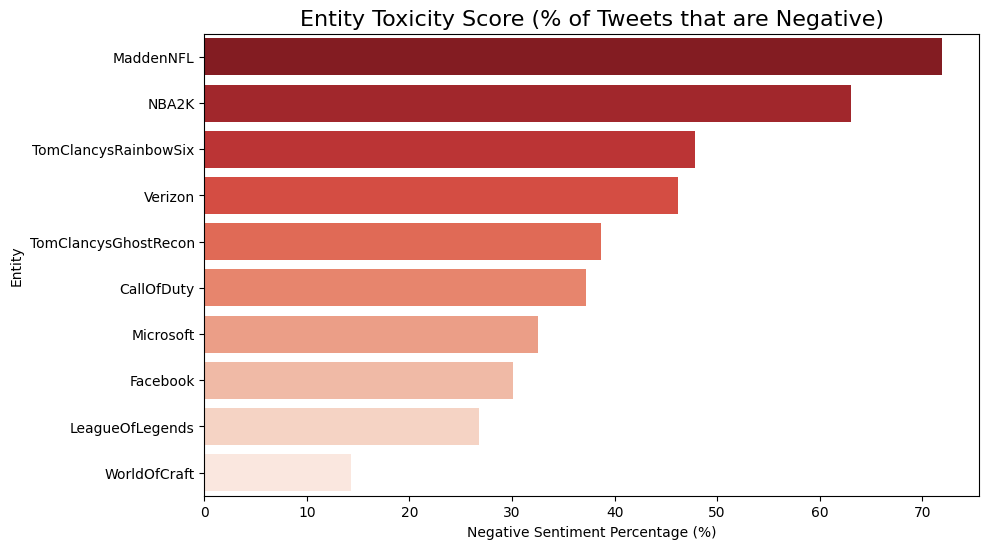

In [23]:
# Calculating a Toxicity Score: (Negative / Total) * 100
toxicity_score = (sentiment_counts['Negative'] / sentiment_counts.sum(axis=1) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=toxicity_score.values, y=toxicity_score.index, palette='Reds_r', hue=toxicity_score.index, legend=False)
plt.title('Entity Toxicity Score (% of Tweets that are Negative)', fontsize=16)
plt.xlabel('Negative Sentiment Percentage (%)')
plt.show()